# M3FS-Net: Mobile 3-Scale Feature Selection Network
Dual-channel: MobileNetV2 (ImageNet) + Enhanced 3DB + Soft SBFS


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os,time,random,warnings,shutil,json,gc,copy,math
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
import torchvision.transforms as T
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
warnings.filterwarnings('ignore')
SEED=42
random.seed(SEED);np.random.seed(SEED);torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available(): print(torch.cuda.get_device_name(0))


Mounted at /content/drive
Device: cuda
Tesla T4


## Configuration


In [2]:
DATASETS={
 'MDS':{'root':'/content/drive/MyDrive/MDS',
  'classes':['Bacterial_leaf_blight','Blast','Brown_spot','Tungro'],'spc':1300},
 'CDS':{'root':'/content/drive/MyDrive/CDS',
  'classes':['Blight','Common Rust','Gray Leaf Spot','Healthy'],'spc':510},
 'TDDS':{'root':'/content/drive/MyDrive/TDDS',
  'classes':['Bacterial_Spot','Early_Blight','Healthy','Late_Blight',
   'Leaf_Mold','Mosaic_Virus','Septoria_Leaf_Spot','Spider_Mites',
   'Target_Spot','Yellow_Leaf_Curl_Virus'],'spc':500},
}
IMG=224;BS=32;EPOCHS=30;PATIENCE=5;ALPHA=128;BETA=96
DRIVE_SAVE='/content/drive/MyDrive/M3FS_Net_Results'
CACHE_ROOT='/content/cache'
VALID_EXT=('.jpg','.jpeg','.png','.bmp','.tif','.tiff')
IMEAN=[0.485,0.456,0.406];ISTD=[0.229,0.224,0.225]
for ds in DATASETS: os.makedirs(f'{DRIVE_SAVE}/checkpoints/{ds}',exist_ok=True)
os.makedirs(CACHE_ROOT,exist_ok=True)
print('Config set.')


Config set.


## M3FS-Net Architecture


In [14]:
class SEBlock(nn.Module):
    def __init__(self,c,r=4):
        super().__init__()
        self.fc=nn.Sequential(nn.Linear(c,c//r),nn.ReLU(),nn.Linear(c//r,c),nn.Sigmoid())
    def forward(self,x):
        w=x.mean(dim=(-2,-1))
        w=self.fc(w).unsqueeze(-1).unsqueeze(-1)
        return x*w

class Enhanced3DB(nn.Module):
    def __init__(self,in_c=3,mid=128,out_c=256):
        super().__init__()
        def block(d):
            return nn.Sequential(
                nn.Conv2d(in_c,mid,1),nn.BatchNorm2d(mid),nn.ReLU(),
                nn.Conv2d(mid,mid,3,padding=d,dilation=d),nn.BatchNorm2d(mid),nn.ReLU())
        self.b1=block(1);self.b2=block(2);self.b3=block(4)
        self.pool1=nn.AdaptiveAvgPool2d(14)
        self.pool2=nn.AdaptiveAvgPool2d(28)
        self.pool3=nn.AdaptiveAvgPool2d(56)
        self.out_pool=nn.AdaptiveAvgPool2d(7)
        self.fuse=nn.Sequential(nn.Conv2d(mid*3,out_c,1),nn.BatchNorm2d(out_c),nn.ReLU())
        self.se=SEBlock(out_c)
    def forward(self,x):
        o1=self.out_pool(self.b1(self.pool1(x)))
        o2=self.out_pool(self.b2(self.pool2(x)))
        o3=self.out_pool(self.b3(self.pool3(x)))
        out=self.fuse(torch.cat([o1,o2,o3],dim=1))
        return self.se(out)

class SoftSBFS(nn.Module):
    def __init__(self,in_c,select_k,r=4):
        super().__init__()
        self.k=select_k
        self.se=nn.Sequential(
            nn.Linear(in_c,in_c//r),nn.ReLU(),nn.Linear(in_c//r,in_c),nn.Sigmoid())
    def _stats(self,x):
        B,C,H,W=x.shape
        xf=x.reshape(B,C,-1)
        mu=xf.mean(-1,keepdim=True)
        std=xf.std(-1,keepdim=True)+1e-6
        cv=(std/(mu.abs()+1e-6)).squeeze(-1).mean(0)
        diff=xf-mu
        kurt=(diff**4).mean(-1)/((std.squeeze(-1))**4+1e-6)-3
        kurt=kurt.clamp(-10,10).mean(0)
        p=F.softmax(xf.abs(),dim=-1)
        ent=-(p*torch.log(p+1e-8)).sum(-1).mean(0)
        q25=xf.quantile(0.25,dim=-1).mean(0)
        q75=xf.quantile(0.75,dim=-1).mean(0)
        iqr=q75-q25
        def norm(t): return (t-t.min())/(t.max()-t.min()+1e-8)
        return (norm(cv)+norm(kurt)+norm(ent)+norm(iqr))/4
    def forward(self,x):
        B,C,H,W=x.shape
        stat=self._stats(x)
        gap=x.mean(dim=(-2,-1))
        learned=self.se(gap).mean(0)
        score=stat*learned
        _,idx=score.topk(self.k)
        idx_sorted,_=idx.sort()
        selected=x[:,idx_sorted,:,:]
        weights=F.softmax(score[idx_sorted],dim=0)
        return selected*weights.unsqueeze(0).unsqueeze(-1).unsqueeze(-1)*self.k


class M3FSNet(nn.Module):
    def __init__(self,nc,alpha=128,beta=96):
        super().__init__()
        mob=models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        self.backbone=mob.features
        for i,layer in enumerate(self.backbone):
            if i<14:
                for p in layer.parameters(): p.requires_grad=False
        self.sbfs1=SoftSBFS(1280,alpha)
        self.tdb=Enhanced3DB(3,128,256)
        self.sbfs2=SoftSBFS(256,beta)
        fused=alpha+beta
        self.fusion=nn.Sequential(
            nn.Conv2d(fused,128,3,padding=2,dilation=2),nn.BatchNorm2d(128),nn.ReLU())
        self.head=nn.Sequential(
            nn.AdaptiveAvgPool2d(1),nn.Flatten(),
            nn.Linear(128,256),nn.ReLU(),nn.Dropout(0.3),nn.Linear(256,nc))
    def forward(self,x):
        f1=self.backbone(x)
        f1=self.sbfs1(f1)
        f2=self.tdb(x)
        f2=self.sbfs2(f2)
        fc=torch.cat([f1,f2],dim=1)
        fc=self.fusion(fc)
        return self.head(fc)

# Quick shape test
_m=M3FSNet(4).to(device)
_t=torch.randn(2,3,224,224).to(device)
_o=_m(_t)
assert _o.shape==(2,4),f'Bad shape:{_o.shape}'
print(f'M3FS-Net OK. Output:{_o.shape}')
del _m,_t,_o;torch.cuda.empty_cache()


M3FS-Net OK. Output:torch.Size([2, 4])


## Helpers


In [5]:
def ckpt(ds,fn): return f'{DRIVE_SAVE}/checkpoints/{ds}/{fn}'

class DiseaseDS(Dataset):
    def __init__(self,paths,labels,tfm=None):
        self.p=paths;self.l=labels;self.t=tfm
    def __len__(self): return len(self.p)
    def __getitem__(self,i):
        img=Image.open(self.p[i]).convert('RGB')
        if self.t: img=self.t(img)
        return img,self.l[i]

train_tfm=T.Compose([T.RandomResizedCrop(IMG,scale=(0.8,1.0)),
    T.RandomHorizontalFlip(),T.RandomVerticalFlip(),T.RandomRotation(15),
    T.ColorJitter(0.2,0.2,0.2,0.05),T.ToTensor(),T.Normalize(IMEAN,ISTD)])
eval_tfm=T.Compose([T.Resize(256),T.CenterCrop(IMG),T.ToTensor(),T.Normalize(IMEAN,ISTD)])

def load_split(ds_name,cfg):
    sp=ckpt(ds_name,'split.json')
    if os.path.exists(sp):
        with open(sp) as f: d=json.load(f)
        print(f'  [CACHED] split: tr={len(d["tp"])},va={len(d["vp"])},te={len(d["ep"])}')
        return d['tp'],d['tl'],d['vp'],d['vl'],d['ep'],d['el']
    src=f'{CACHE_ROOT}/{ds_name}'
    paths,labels=[],[]
    for ci,c in enumerate(cfg['classes']):
        cd=os.path.join(src,c)
        imgs=[os.path.join(cd,f) for f in os.listdir(cd) if f.lower().endswith(VALID_EXT)]
        random.seed(SEED);chosen=random.sample(imgs,cfg['spc'])
        paths.extend(chosen);labels.extend([ci]*cfg['spc'])
    tp,xp,tl,xl=train_test_split(paths,labels,test_size=0.3,stratify=labels,random_state=SEED)
    vp,ep,vl,el=train_test_split(xp,xl,test_size=2/3,stratify=xl,random_state=SEED)
    with open(sp,'w') as f: json.dump({'tp':tp,'tl':tl,'vp':vp,'vl':vl,'ep':ep,'el':el},f)
    print(f'  Split: tr={len(tp)},va={len(vp)},te={len(ep)}')
    return tp,tl,vp,vl,ep,el

def compute_metrics(yt,yp,nc):
    cm=confusion_matrix(yt,yp,labels=list(range(nc)))
    tpr,fpr,tnr=[],[],[]
    for i in range(nc):
        TP=cm[i,i];FN=cm[i,:].sum()-TP;FP=cm[:,i].sum()-TP;TN=cm.sum()-TP-FP-FN
        tpr.append(TP/(TP+FN+1e-8));fpr.append(FP/(FP+TN+1e-8));tnr.append(TN/(TN+FP+1e-8))
    return {'ACC':round(float(accuracy_score(yt,yp)),4),
        'TPR':round(float(np.mean(tpr)),4),'FPR':round(float(np.mean(fpr)),4),
        'TNR':round(float(np.mean(tnr)),4),
        'F1':round(float(f1_score(yt,yp,average='macro',zero_division=0)),4)}
print('Helpers ready.')


Helpers ready.


## Dataset Verification


In [6]:
all_ok=True
for dn,cfg in DATASETS.items():
    r=cfg['root'];print(f'-- {dn} --')
    if not os.path.isdir(r): print(f'  MISSING:{r}');all_ok=False;continue
    for c in cfg['classes']:
        cd=os.path.join(r,c)
        if not os.path.isdir(cd): print(f'  MISSING:{c}');all_ok=False;continue
        n=len([f for f in os.listdir(cd) if f.lower().endswith(VALID_EXT)])
        ok=n>=cfg['spc']
        if not ok: all_ok=False
        print(f'  {"ok" if ok else "FAIL":>4s} {c:<30s} {n:>5} (need {cfg["spc"]})')
assert all_ok,'Verification failed'
print('All verified.')


-- MDS --
    ok Bacterial_leaf_blight           1584 (need 1300)
    ok Blast                           1440 (need 1300)
    ok Brown_spot                      1600 (need 1300)
    ok Tungro                          1308 (need 1300)
-- CDS --
    ok Blight                           985 (need 510)
    ok Common Rust                     1192 (need 510)
    ok Gray Leaf Spot                   513 (need 510)
    ok Healthy                         1162 (need 510)
-- TDDS --
    ok Bacterial_Spot                   500 (need 500)
    ok Early_Blight                     500 (need 500)
    ok Healthy                          500 (need 500)
    ok Late_Blight                      500 (need 500)
    ok Leaf_Mold                        500 (need 500)
    ok Mosaic_Virus                     500 (need 500)
    ok Septoria_Leaf_Spot               500 (need 500)
    ok Spider_Mites                     500 (need 500)
    ok Target_Spot                      500 (need 500)
    ok Yellow_Leaf_Curl_Virus 

## Cache to Local


In [7]:
for dn,cfg in DATASETS.items():
    cd=f'{CACHE_ROOT}/{dn}'
    if os.path.exists(cd):
        ex=[d for d in os.listdir(cd) if os.path.isdir(os.path.join(cd,d))]
        if len(ex)>=len(cfg['classes']): print(f'[CACHED] {dn}');continue
        shutil.rmtree(cd)
    print(f'Caching {dn}...');t0=time.time()
    shutil.copytree(cfg['root'],cd);print(f'  {time.time()-t0:.1f}s')
print('All cached.')


Caching MDS...
  124.5s
Caching CDS...
  94.4s
Caching TDDS...
  77.8s
All cached.


## DataLoaders


In [8]:
loaders={}
for dn,cfg in DATASETS.items():
    print(f'\n-- {dn} --')
    tp,tl,vp,vl,ep,el=load_split(dn,cfg)
    loaders[dn]={'train':DataLoader(DiseaseDS(tp,tl,train_tfm),batch_size=BS,shuffle=True,num_workers=2,pin_memory=True),
        'val':DataLoader(DiseaseDS(vp,vl,eval_tfm),batch_size=BS,shuffle=False,num_workers=2,pin_memory=True),
        'test':DataLoader(DiseaseDS(ep,el,eval_tfm),batch_size=BS,shuffle=False,num_workers=2,pin_memory=True),
        'nc':len(cfg['classes'])}
    print(f'  tr={len(tp)} va={len(vp)} te={len(ep)}')
print('\nAll DataLoaders ready.')



-- MDS --
  Split: tr=3640,va=520,te=1040
  tr=3640 va=520 te=1040

-- CDS --
  Split: tr=1428,va=204,te=408
  tr=1428 va=204 te=408

-- TDDS --
  Split: tr=3500,va=500,te=1000
  tr=3500 va=500 te=1000

All DataLoaders ready.


## Train M3FS-Net on All Datasets


In [19]:
all_results=[]

for dn,cfg in DATASETS.items():
    print(f'\n{"="*60}\n  {dn}\n{"="*60}')
    nc=loaders[dn]['nc']
    res_p=ckpt(dn,'result.json')
    if os.path.exists(res_p):
        with open(res_p) as f: m=json.load(f)
        m['Dataset']=dn;all_results.append(m)
        print(f'  [CACHED] ACC={m["ACC"]}');continue

    model=M3FSNet(nc,ALPHA,BETA).to(device)
    backbone_p=[p for n,p in model.named_parameters() if 'backbone' in n and p.requires_grad]
    new_p=[p for n,p in model.named_parameters() if 'backbone' not in n and p.requires_grad]
    optimizer=torch.optim.Adam([{'params':backbone_p,'lr':1e-4},{'params':new_p,'lr':1e-3}])
    scheduler=torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer,T_0=10)
    criterion=nn.CrossEntropyLoss()

    start_ep=0;best_vl=float('inf');pat=0
    best_w=copy.deepcopy(model.state_dict())
    ckpt_p=ckpt(dn,'train_ckpt.pt')
    if os.path.exists(ckpt_p):
        try:
            sv=torch.load(ckpt_p,map_location=device,weights_only=False)
            model.load_state_dict(sv['ms']);optimizer.load_state_dict(sv['os'])
            start_ep=sv['ep']+1;best_vl=sv['bvl'];pat=sv['pat'];best_w=sv['bw']
            print(f'  Resumed from epoch {start_ep}')
        except: print('  Bad checkpoint, fresh start')

    train_dl=loaders[dn]['train'];val_dl=loaders[dn]['val'];test_dl=loaders[dn]['test']

    for ep in range(start_ep,EPOCHS):
        if pat>=PATIENCE: print(f'  Early stop at epoch {ep}');break
        model.train()
        tl_sum=tc=tt=0
        for imgs,lbls in train_dl:
            imgs,lbls=imgs.to(device),lbls.long().to(device)
            optimizer.zero_grad()
            out=model(imgs);loss=criterion(out,lbls)
            loss.backward();optimizer.step()
            tl_sum+=loss.item()*imgs.size(0)
            tc+=(out.argmax(1)==lbls).sum().item();tt+=imgs.size(0)
        scheduler.step()

        model.eval()
        vl_sum=vc=vt=0
        with torch.no_grad():
            for imgs,lbls in val_dl:
                imgs,lbls=imgs.to(device),lbls.long().to(device)
                out=model(imgs);loss=criterion(out,lbls)
                vl_sum+=loss.item()*imgs.size(0)
                vc+=(out.argmax(1)==lbls).sum().item();vt+=imgs.size(0)

        tl=tl_sum/tt;ta=tc/tt;vl=vl_sum/vt;va=vc/vt
        print(f'  Ep {ep+1}/{EPOCHS} tl={tl:.4f} ta={ta:.4f} vl={vl:.4f} va={va:.4f}')

        if vl<best_vl: best_vl=vl;pat=0;best_w=copy.deepcopy(model.state_dict())
        else: pat+=1

        torch.save({'ep':ep,'ms':model.state_dict(),'os':optimizer.state_dict(),
            'bvl':best_vl,'pat':pat,'bw':best_w},ckpt_p)

    # ── TTA Evaluation ──
    model.load_state_dict(best_w);model.eval()
    tta_tfm=T.Compose([T.RandomResizedCrop(IMG,scale=(0.85,1.0)),
        T.RandomHorizontalFlip(),T.RandomVerticalFlip(),
        T.ToTensor(),T.Normalize(IMEAN,ISTD)])
    test_paths=loaders[dn]['test'].dataset.p
    test_labels=loaders[dn]['test'].dataset.l
    n_tta=5
    all_logits=[]
    labs=[]
    with torch.no_grad():
        for t in range(n_tta):
            use_tfm=eval_tfm if t==0 else tta_tfm
            tmp_dl=DataLoader(DiseaseDS(test_paths,test_labels,use_tfm),batch_size=BS,shuffle=False,num_workers=2,pin_memory=True)
            run_logits=[]
            for imgs,lbls in tmp_dl:
                run_logits.append(model(imgs.to(device)).cpu())
                if t==0: labs.extend(lbls.tolist())
            all_logits.append(torch.cat(run_logits))
    avg=torch.stack(all_logits).mean(0)
    preds=avg.argmax(1).tolist()

    m=compute_metrics(labs,preds,nc)
    m['Dataset']=dn;all_results.append(m)
    with open(res_p,'w') as f:
        json.dump({k:v for k,v in m.items() if k!='Dataset'},f)
    print(f'  TEST: ACC={m["ACC"]} TPR={m["TPR"]} FPR={m["FPR"]} TNR={m["TNR"]} F1={m["F1"]}')
    del model,optimizer,best_w;torch.cuda.empty_cache();gc.collect()
    if os.path.exists(ckpt_p): os.remove(ckpt_p)

print('\nAll done.')


  MDS
  [CACHED] ACC=0.9981

  CDS
  Ep 1/30 tl=0.9029 ta=0.5917 vl=0.5949 va=0.7304
  Ep 2/30 tl=0.5034 ta=0.7752 vl=0.3933 va=0.8529
  Ep 3/30 tl=0.3707 ta=0.8515 vl=0.3920 va=0.8137
  Ep 4/30 tl=0.2752 ta=0.8950 vl=0.3014 va=0.8725
  Ep 5/30 tl=0.2432 ta=0.9027 vl=0.2769 va=0.8922
  Ep 6/30 tl=0.2079 ta=0.9223 vl=0.2917 va=0.8922
  Ep 7/30 tl=0.1816 ta=0.9223 vl=0.2861 va=0.8676
  Ep 8/30 tl=0.2030 ta=0.9174 vl=0.2733 va=0.8725
  Ep 9/30 tl=0.1774 ta=0.9363 vl=0.2671 va=0.8922
  Ep 10/30 tl=0.2037 ta=0.9230 vl=0.2910 va=0.8775
  Ep 11/30 tl=0.2129 ta=0.9202 vl=0.3209 va=0.8627
  Ep 12/30 tl=0.2141 ta=0.9125 vl=0.2810 va=0.8971
  Ep 13/30 tl=0.2021 ta=0.9181 vl=0.2118 va=0.9412
  Ep 14/30 tl=0.1901 ta=0.9174 vl=0.2227 va=0.9216
  Ep 15/30 tl=0.1767 ta=0.9300 vl=0.2542 va=0.9118
  Ep 16/30 tl=0.1770 ta=0.9342 vl=0.2791 va=0.9118
  Ep 17/30 tl=0.1604 ta=0.9433 vl=0.2371 va=0.9216
  Ep 18/30 tl=0.1616 ta=0.9307 vl=0.2342 va=0.9167
  Early stop at epoch 18
  TEST: ACC=0.9608 TPR=0.9608 

## Final Results


In [20]:
df=pd.DataFrame(all_results)
df=df[['Dataset','ACC','TPR','FPR','TNR','F1']]
df.insert(1,'Model','M3FS-Net')
csv_p=f'{DRIVE_SAVE}/m3fs_final_results.csv'
df.to_csv(csv_p,index=False)
print(f'Saved: {csv_p}\n')
display(df.style.format({c:'{:.4f}' for c in ['ACC','TPR','FPR','TNR','F1']})
    .background_gradient(cmap='RdYlGn',subset=['ACC','TPR','TNR','F1'])
    .background_gradient(cmap='RdYlGn_r',subset=['FPR'])
    .set_caption('M3FS-Net Results'))


Saved: /content/drive/MyDrive/M3FS_Net_Results/m3fs_final_results.csv



,Dataset,Model,ACC,TPR,FPR,TNR,F1
0,MDS,M3FS-Net,0.9981,0.9981,0.0006,0.9994,0.9981
1,CDS,M3FS-Net,0.9608,0.9608,0.0131,0.9869,0.9606
2,TDDS,M3FS-Net,0.9710,0.9710,0.0032,0.9968,0.9710


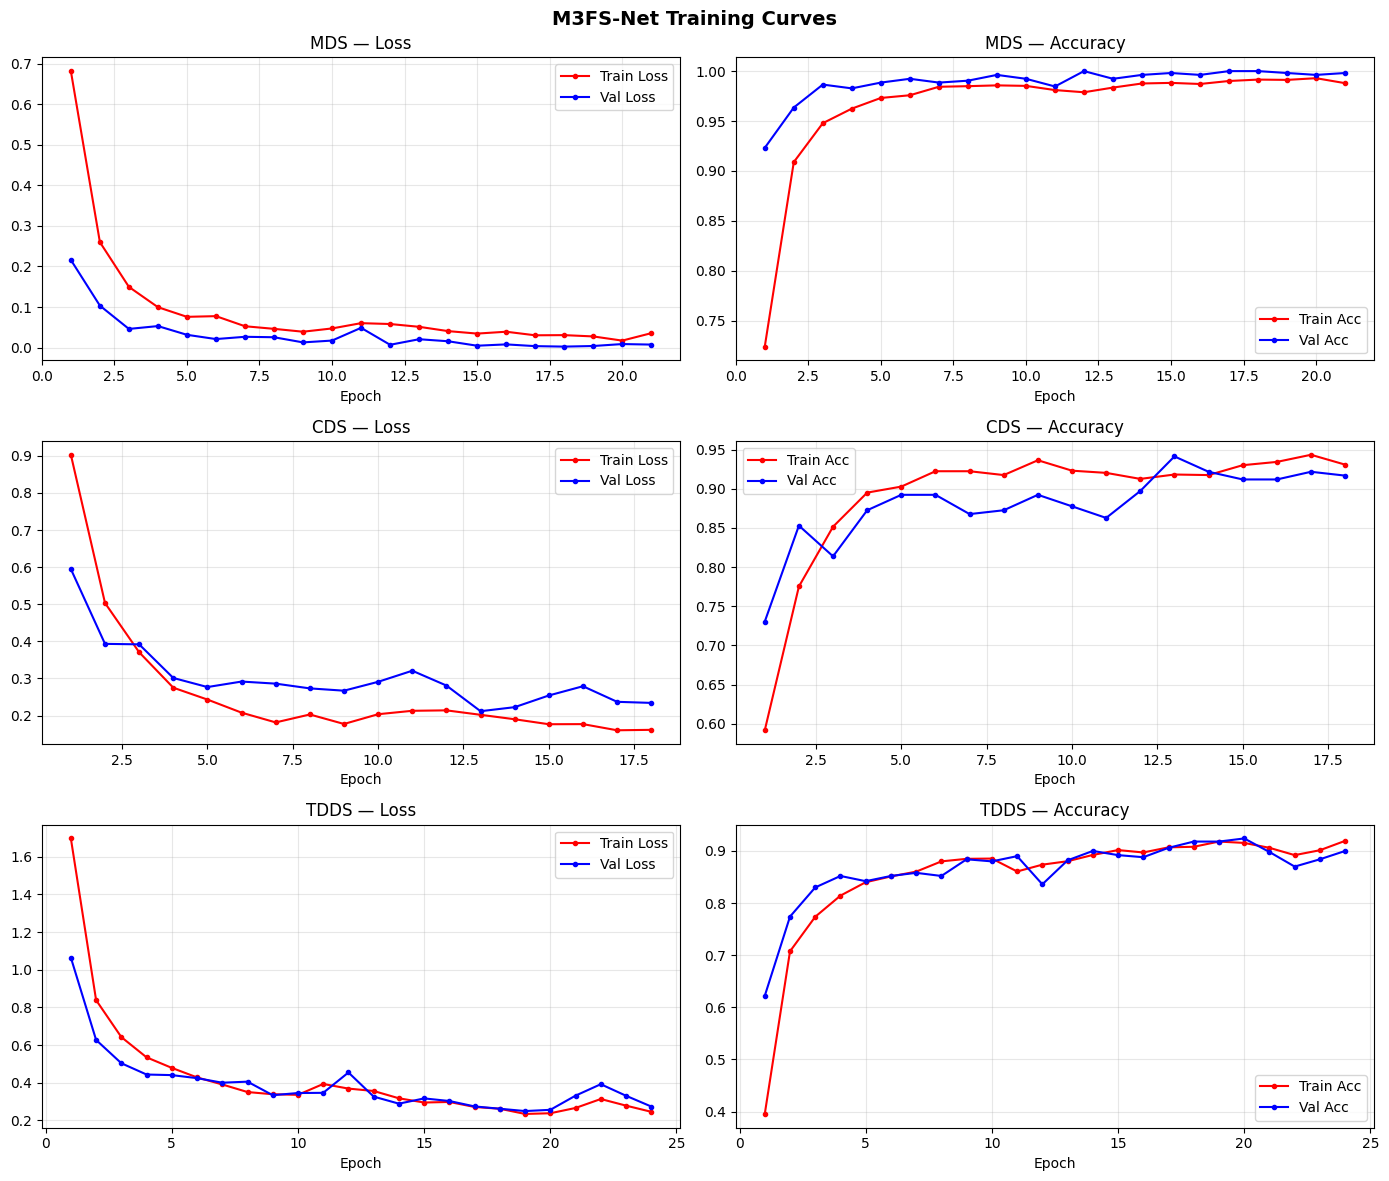

Saved: /content/drive/MyDrive/M3FS_Net_Results/training_curves.png


In [21]:
import matplotlib.pyplot as plt

# MDS data from earlier run (epochs 1-21, early stopped)
mds = {'tl':[0.6814,0.2599,0.1496,0.0996,0.0758,0.0775,0.0526,0.0462,0.0391,0.0472,0.0602,0.0581,0.0512,0.0406,0.0345,0.0391,0.0303,0.0307,0.0275,0.0172,0.0355],
       'ta':[0.7239,0.9088,0.9478,0.9624,0.9731,0.9758,0.9843,0.9849,0.9857,0.9852,0.9810,0.9788,0.9835,0.9876,0.9882,0.9871,0.9901,0.9915,0.9912,0.9929,0.9879],
       'vl':[0.2160,0.1034,0.0460,0.0530,0.0315,0.0210,0.0266,0.0255,0.0128,0.0173,0.0487,0.0069,0.0206,0.0156,0.0046,0.0079,0.0036,0.0024,0.0039,0.0087,0.0074],
       'va':[0.9231,0.9635,0.9865,0.9827,0.9885,0.9923,0.9885,0.9904,0.9962,0.9923,0.9846,1.0,0.9923,0.9962,0.9981,0.9962,1.0,1.0,0.9981,0.9962,0.9981]}

cds = {'tl':[0.9029,0.5034,0.3707,0.2752,0.2432,0.2079,0.1816,0.2030,0.1774,0.2037,0.2129,0.2141,0.2021,0.1901,0.1767,0.1770,0.1604,0.1616],
       'ta':[0.5917,0.7752,0.8515,0.8950,0.9027,0.9223,0.9223,0.9174,0.9363,0.9230,0.9202,0.9125,0.9181,0.9174,0.9300,0.9342,0.9433,0.9307],
       'vl':[0.5949,0.3933,0.3920,0.3014,0.2769,0.2917,0.2861,0.2733,0.2671,0.2910,0.3209,0.2810,0.2118,0.2227,0.2542,0.2791,0.2371,0.2342],
       'va':[0.7304,0.8529,0.8137,0.8725,0.8922,0.8922,0.8676,0.8725,0.8922,0.8775,0.8627,0.8971,0.9412,0.9216,0.9118,0.9118,0.9216,0.9167]}

tdds = {'tl':[1.697,0.8385,0.6423,0.5348,0.4788,0.4282,0.3907,0.3505,0.3388,0.3356,0.3934,0.3688,0.3561,0.3173,0.2949,0.2978,0.2712,0.2618,0.2342,0.2379,0.2660,0.3135,0.2784,0.2456],
        'ta':[0.3954,0.7074,0.7737,0.8143,0.8400,0.8511,0.8603,0.8800,0.8849,0.8854,0.8606,0.8737,0.8803,0.8923,0.9017,0.8971,0.9069,0.9080,0.9180,0.9154,0.9060,0.8920,0.9014,0.9194],
        'vl':[1.0641,0.6272,0.5034,0.4435,0.4404,0.4243,0.4001,0.4056,0.3337,0.3453,0.3463,0.4544,0.3263,0.2888,0.3167,0.3029,0.2741,0.2619,0.2495,0.2561,0.3314,0.3921,0.3308,0.2736],
        'va':[0.622,0.774,0.830,0.852,0.842,0.852,0.858,0.852,0.884,0.880,0.890,0.836,0.882,0.900,0.892,0.888,0.906,0.918,0.918,0.924,0.898,0.870,0.884,0.900]}

fig,axes=plt.subplots(3,2,figsize=(14,12))
for i,(name,d) in enumerate([('MDS',mds),('CDS',cds),('TDDS',tdds)]):
    eps=range(1,len(d['tl'])+1)
    axes[i,0].plot(eps,d['tl'],'r-o',ms=3,label='Train Loss')
    axes[i,0].plot(eps,d['vl'],'b-o',ms=3,label='Val Loss')
    axes[i,0].set_title(f'{name} — Loss');axes[i,0].legend();axes[i,0].set_xlabel('Epoch');axes[i,0].grid(True,alpha=0.3)
    axes[i,1].plot(eps,d['ta'],'r-o',ms=3,label='Train Acc')
    axes[i,1].plot(eps,d['va'],'b-o',ms=3,label='Val Acc')
    axes[i,1].set_title(f'{name} — Accuracy');axes[i,1].legend();axes[i,1].set_xlabel('Epoch');axes[i,1].grid(True,alpha=0.3)
plt.suptitle('M3FS-Net Training Curves',fontsize=14,fontweight='bold')
plt.tight_layout();plt.savefig(f'{DRIVE_SAVE}/training_curves.png',dpi=150,bbox_inches='tight');plt.show()
print(f'Saved: {DRIVE_SAVE}/training_curves.png')


In [22]:
for nc, label in [(4,'MDS/CDS'), (10,'TDDS')]:
    m = M3FSNet(nc, ALPHA, BETA)
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    frozen = total - trainable
    print(f'{label} ({nc} classes):')
    print(f'  Total:     {total:>12,}')
    print(f'  Trainable: {trainable:>12,}')
    print(f'  Frozen:    {frozen:>12,}')
    print()
    del m


MDS/CDS (4 classes):
  Total:        3,948,228
  Trainable:    3,405,700
  Frozen:         542,528

TDDS (10 classes):
  Total:        3,949,770
  Trainable:    3,407,242
  Frozen:         542,528

